In [1]:
!ls ./data/ --color=auto

annotations.txt  tmp  videos


In [2]:
!ls ./data/videos/* | wc

    581     570    7987


In [3]:
!ls ./data/videos/* | head

./data/videos/note.txt

./data/videos/101-150:
idx20-101.mp4
idx20-102.mp4
idx20-103.mp4
idx20-104.mp4
idx20-105.mp4
idx20-106.mp4
idx20-107.mp4


In [4]:
!cat ./data/annotations.txt | head -n 30

မီး ။	မီး
မီး ငြှိမ်း ။	မီး ငြှိမ်း
မီးချိတ် ။	မီးချိတ်
မီးကပ် ။	မီးကပ်
ရေပုံး ။	ရေပုံး
သဲ အိတ် ။	အိတ် ထဲ သဲ
မီးသတ်ဆေးဘူး ။	အနီ ဘူး ဖြန်း
မီးသတ်ရေကန် ။	ကန် ထဲ ရေ သိမ်း
မီးလောင် လွယ် သော ပစ္စည်း များ ။	မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
လောင်စာဆီ ။	ဓာတ်ဆီ 9 2 9 5 အောက်တိန်း အမျိုးမျိုး
အမှိုက် ။	အမှိုက်
လျှပ်စစ် မီး ။	မီး လျှပ်စစ်
ဂက်စ် မီး ။	အဖြူ ဂက်စ်
မီးကြွင်းမီးကျန် ။	မီးကြွင်းမီးကျန်
မီးခလုပ် ။	ခလုပ် နှိပ်
မီးခြစ် ။	မီးခြစ်
ဖယောင်းတိုင် ။	ဖယောင်းတိုင်
ခြင်ဆေးခွေ ။	ခြင် ဆေးခွေ
အမွှေးတိုင် ။	အမွှေးတိုင်
မီးခိုး ။	မီး အခိုးအငွေ့ အမဲ
အောက်စီဂျင် ။	အောက်ဆီဂျင် o 2
ထွက်ပေါက် ။	ဆိုင်းဘုတ် အဲဒီက ပြေး တံခါးပေါက်
မီးသတ်ကား ။	ကား အရေးပေါ် မီးသတ်
မီးသတ်သမား ။	မီးသတ်သမား
မီးသတ်ဌာန ။	မီးသတ် အိမ် ထဲ
လျှပ်စစ် ဝါယာ ရှော့ ။	လျှပ်စစ် ကြိုး ရှော့
ရေဘေး ။	ရေ ကြီး
ဘေးအန္တရာယ် ။	သဘာဝ ဒုက္ခ
မြစ်ခေျာင်း ။	ရေ ချောင်း
မြေနိမ့်ဒေသ ။	မြေနိမ့် အဲ့နေရာ
cat: write error: Broken pipe


## Python Codes

In [6]:
!ls ./src/*.py

./src/augment.py	 ./src/extract_keypoints.py  ./src/plot_results_v2.py
./src/cross_validate.py  ./src/infer_onnx.py	     ./src/prepare_data.py
./src/dataset.py	 ./src/infer.py		     ./src/train.py
./src/evaluate.py	 ./src/__init__.py	     ./src/utils.py
./src/export_to_onnx.py  ./src/plot_results.py


In [7]:
!ls ./tools/*.py

./tools/lookup_video_label.py  ./tools/probe_mediapipe.py


In [9]:
!ls ./scripts/*.sh --color=auto

./scripts/00_setup_env.sh          ./scripts/06_run_all_experiments.sh
./scripts/01_prepare_data.sh       ./scripts/07_cross_validate.sh
./scripts/02_extract_keypoints.sh  ./scripts/08_infer.sh
./scripts/03_augment_data.sh       ./scripts/09_tensorboard.sh
./scripts/04_train.sh              ./scripts/move_videos.sh
./scripts/05_evaluate.sh


## 01. Prepare Data

In [10]:
from IPython.display import Markdown

# Read the file content
with open('./scripts/01_prepare_data.sh', 'r') as f:
    content = f.read()

# Display it as a highlighted Bash block
display(Markdown(f"```bash\n{content}\n```"))

```bash
#!/usr/bin/env bash
# =============================================================================
# 01_prepare_data.sh  –  Parse annotations, build vocab, create splits
# =============================================================================
# Run ONCE before any training.
# Edit DATA_DIR and ANNOTATION_FILE to match your setup.
# =============================================================================

set -euo pipefail

# ── USER SETTINGS ─────────────────────────────────────────────────────────────
DATA_DIR="data"
VIDEO_DIR="${DATA_DIR}/videos"
ANNOTATION_FILE="${DATA_DIR}/annotations.txt"
CONFIG="config/config.yaml"
LOG_DIR="results/logs"
# ─────────────────────────────────────────────────────────────────────────────

mkdir -p "${LOG_DIR}"

echo "============================================================"
echo " Step 1 — Data Preparation"
echo "============================================================"
echo " Video dir       : ${VIDEO_DIR}"
echo " Annotation file : ${ANNOTATION_FILE}"
echo ""

# Verify annotation file exists
if [[ ! -f "${ANNOTATION_FILE}" ]]; then
    echo "[ERROR] Annotation file not found: ${ANNOTATION_FILE}"
    echo ""
    echo "  Expected format (tab-delimited, one line per sign):"
    echo "  မီးချိတ် ။<TAB>မီးချိတ်"
    echo "  သဲ အိတ် ။<TAB>အိတ် ထဲ သဲ"
    echo ""
    echo "  → Place your annotation file at: ${ANNOTATION_FILE}"
    exit 1
fi

# Verify video directory exists
if [[ ! -d "${VIDEO_DIR}" ]]; then
    echo "[WARNING] Video directory not found: ${VIDEO_DIR}"
    echo "  → Download MSL4Emergency videos from GitHub and place them in ${VIDEO_DIR}"
    echo "  → Continuing with annotation-only preparation…"
fi

# Count videos
N_VIDEOS=$(find "${VIDEO_DIR}" -name "*.mp4" -o -name "*.avi" -o -name "*.mov" \
           -o -name "*.MP4" 2>/dev/null | wc -l || echo 0)
N_ANNS=$(grep -c "." "${ANNOTATION_FILE}" || echo 0)

echo " Found ${N_VIDEOS} videos and ${N_ANNS} annotation lines"
echo ""

# Run preparation
python src/prepare_data.py \
    --config "${CONFIG}" \
    --verify_keypoints \
    2>&1 | tee "${LOG_DIR}/prepare_data.log"

echo ""
echo "============================================================"
echo " Data preparation done!"
echo " Outputs:"
echo "   data/label_map.json   ← class vocab"
echo "   data/splits.json      ← train/val/test indices"
echo "   data/kfold_splits.json← 5-fold CV splits"
echo " Next: run 02_extract_keypoints.sh"
echo "============================================================"

```

In [12]:
!chmod +x ./scripts/*.sh

In [13]:
!time ./scripts/01_prepare_data.sh

 Step 1 — Data Preparation
 Video dir       : data/videos
 Annotation file : data/annotations.txt

 Found 558 videos and 558 annotation lines

2026-07-19 21:07:23 | INFO     | prepare_data | ============================================================
2026-07-19 21:07:23 | INFO     | prepare_data | MSL Data Preparation
2026-07-19 21:07:23 | INFO     | prepare_data | ============================================================
2026-07-19 21:07:23 | INFO     | prepare_data | Parsing annotation file: data/annotations.txt
2026-07-19 21:07:23 | INFO     | prepare_data | Total annotation records: 558
2026-07-19 21:07:23 | INFO     | prepare_data | Vocabulary built: 556 unique classes
2026-07-19 21:07:23 | INFO     | prepare_data | Label map saved → data/label_map.json
2026-07-19 21:07:23 | INFO     | prepare_data | Matching videos from: data/videos

Dataset Statistics [full]
  Total samples    : 558
  Classes (present): 556 / 556 total
  Samples/class    : min=1, max=2, mean=1.00
  Size dist

In [14]:
!ls ./data/ --color=auto

annotations.txt  kfold_splits.json  label_map.json  splits.json  tmp  videos


In [15]:
!cat ./data/label_map.json | head -n 50

{
  "label2idx": {
    "မီး ။": 0,
    "မီး ငြှိမ်း ။": 1,
    "မီးချိတ် ။": 2,
    "မီးကပ် ။": 3,
    "ရေပုံး ။": 4,
    "သဲ အိတ် ။": 5,
    "မီးသတ်ဆေးဘူး ။": 6,
    "မီးသတ်ရေကန် ။": 7,
    "မီးလောင် လွယ် သော ပစ္စည်း များ ။": 8,
    "လောင်စာဆီ ။": 9,
    "အမှိုက် ။": 10,
    "လျှပ်စစ် မီး ။": 11,
    "ဂက်စ် မီး ။": 12,
    "မီးကြွင်းမီးကျန် ။": 13,
    "မီးခလုပ် ။": 14,
    "မီးခြစ် ။": 15,
    "ဖယောင်းတိုင် ။": 16,
    "ခြင်ဆေးခွေ ။": 17,
    "အမွှေးတိုင် ။": 18,
    "မီးခိုး ။": 19,
    "အောက်စီဂျင် ။": 20,
    "ထွက်ပေါက် ။": 21,
    "မီးသတ်ကား ။": 22,
    "မီးသတ်သမား ။": 23,
    "မီးသတ်ဌာန ။": 24,
    "လျှပ်စစ် ဝါယာ ရှော့ ။": 25,
    "ရေဘေး ။": 26,
    "ဘေးအန္တရာယ် ။": 27,
    "မြစ်ခေျာင်း ။": 28,
    "မြေနိမ့်ဒေသ ။": 29,
    "ချိုင့် ။": 30,
    "ရေနုတ်မြောင်း ။": 31,
    "ရေ လွှမ်းမိုး မှု ။": 32,
    "အရေးပေါ် သုံး ပစ္စည်း ။": 33,
    "မိုးလေဝသ သတင်း ။": 34,
    "လျှပ်တစ်ပြက် ရေကြီး ခြင်း ။": 35,
    "ဘေးလွတ် ရာ နေရာ ။": 36,
    "သောက် သုံး ရေ သန့် ။": 37,
    "ကျိုချက် ထား သော 

In [16]:
!cat ./data/splits.json

{
  "train": [
    0,
    2,
    3,
    4,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    26,
    29,
    31,
    34,
    35,
    37,
    38,
    39,
    41,
    42,
    43,
    45,
    47,
    48,
    49,
    50,
    52,
    53,
    54,
    55,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    72,
    74,
    75,
    76,
    77,
    79,
    82,
    84,
    85,
    86,
    88,
    90,
    91,
    92,
    93,
    96,
    97,
    98,
    100,
    101,
    102,
    103,
    105,
    106,
    109,
    110,
    111,
    113,
    115,
    116,
    118,
    120,
    121,
    122,
    123,
    124,
    129,
    130,
    131,
    132,
    133,
    139,
    140,
    141,
    143,
    144,
    145,
    146,
    147,
    149,
    151,
    152,
    153,
    154,
    155,
    156,
    157,
    158,
    160,
    162,
    164,
    165,
    167,
    168,
    169,
    170,
    171,

In [19]:
!./scripts/02_extract_keypoints.sh

 Step 2 — MediaPipe Holistic Keypoint Extraction
 Video dir     : data/videos
 Output dir    : data/keypoints
 Complexity    : 2
 Overwrite     : false

 Total videos  : 558

2026-07-20 06:33:58.402264: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-20 06:33:59.337052: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
I0000 00:00:1784505841.650773  154612 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1784505841.654527  154662 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: Mesa Intel(R) UHD Graphics 620 (KBL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
I0000 00:00:1784505841.663941  154612 gl_context_egl

In [20]:
!ls ./data/ --color=auto

annotations.txt  kfold_splits.json  splits.json  videos
keypoints        label_map.json     tmp


keypoints ဆိုတဲ့ ဖိုလ်ဒါ ရလာပြီ။ အဲဒီဖိုလ်ဒါထဲကို ဝင်ကြည့်ရအောင်။

In [21]:
!ls ./data/keypoints/* | head -n 30

./data/keypoints/extraction_stats.json

./data/keypoints/101-150:
idx20-101.npy
idx20-101_vis.npy
idx20-102.npy
idx20-102_vis.npy
idx20-103.npy
idx20-103_vis.npy
idx20-104.npy
idx20-104_vis.npy
idx20-105.npy
idx20-105_vis.npy
idx20-106.npy
idx20-106_vis.npy
idx20-107.npy
idx20-107_vis.npy
idx20-108.npy
idx20-108_vis.npy
idx20-109.npy
idx20-109_vis.npy
idx20-110.npy
idx20-110_vis.npy
idx20-111.npy
idx20-111_vis.npy
idx20-112.npy
idx20-112_vis.npy
idx20-113.npy
idx20-113_vis.npy
idx20-114.npy
ls: write error: Broken pipe


In [22]:
!file ./data/keypoints/101-150/idx20-112.npy

./data/keypoints/101-150/idx20-112.npy: NumPy array, version 1.0, header length 118


In [23]:
!file ./data/keypoints/101-150/idx20-112_vis.npy

./data/keypoints/101-150/idx20-112_vis.npy: NumPy array, version 1.0, header length 118


In [24]:
import numpy as np

coords = np.load('./data/keypoints/401-450/idx20-401.npy')
vis = np.load('./data/keypoints/401-450/idx20-401_vis.npy')

print(f"Coordinates shape: {coords.shape}") # Expect: (frames, landmarks, 3)
print(f"Visibility shape: {vis.shape}")     # Expect: (frames, landmarks)

Coordinates shape: (88, 75, 3)
Visibility shape: (88, 33)


In [25]:
import numpy as np

# Load the files
coords = np.load('./data/keypoints/401-450/idx20-401.npy')
vis = np.load('./data/keypoints/401-450/idx20-401_vis.npy')

# 1. Print Shapes
print(f"--- Shapes ---")
print(f"Coordinates shape: {coords.shape}") 
print(f"Visibility shape:  {vis.shape}")
print("-" * 20)

# 2. Print Data Types
print(f"Coordinates dtype: {coords.dtype}")
print(f"Visibility dtype:  {vis.dtype}")
print("-" * 20)

# 3. Peek at the first frame (first time step)
# This shows you the (x, y, z) for all landmarks in the first frame
print(f"--- Sample Data (First Frame) ---")
print(f"First 3 landmark coordinates:\n{coords[0, :3, :]}") 
print(f"\nFirst 3 visibility scores:\n{vis[0, :3]}")

--- Shapes ---
Coordinates shape: (88, 75, 3)
Visibility shape:  (88, 33)
--------------------
Coordinates dtype: float32
Visibility dtype:  float32
--------------------
--- Sample Data (First Frame) ---
First 3 landmark coordinates:
[[-0.01165334 -0.9866077  -1.1664635 ]
 [ 0.04534203 -1.1658978  -1.0596921 ]
 [ 0.08416646 -1.1634829  -1.0623013 ]]

First 3 visibility scores:
[0.9945323  0.98316556 0.98394144]


**./data/keypoints/extraction_stats.json ကိုလည်း လေ့လာရအောင်**

In [27]:
cat ./data/keypoints/extraction_stats.json

{
  "total": 558,
  "processed": 558,
  "failed": 0,
  "skipped": 0,
  "seq_len_min": 50,
  "seq_len_max": 387,
  "seq_len_mean": 130.56810035842295,
  "seq_len_std": 55.11924044288601,
  "seq_len_p50": 119.0,
  "seq_len_p95": 241.14999999999998,
  "lh_mean_presence": 0.6177208780096964,
  "rh_mean_presence": 0.7129535191739758
}

In [28]:
!time ./scripts/03_augment_data.sh

 Step 3 — All-Class Offline Data Augmentation
 Strategy    : all 558 videos → train/val/test by aug type
 Aug factor  : 20x
   Train     : 19 aug copies × 558 = 10602 samples
   Val       : 1 aug copy × 558 = 558 samples
   Test      : 558 originals (no augmentation)
 Class overlap: 100% across all splits

Augmenting all classes: 100%|██████████| 558/558 [00:39<00:00, 14.07sign/s]

  Augmentation Complete (all-class design)
  Original videos   : 558
  Aug factor        : 20  (train uses 19, val uses 1)
  Train samples     : 10602  (augmented, all classes)
  Val   samples     : 558   (augmented, all classes)
  Test  samples     : 558   (original,  all classes)
  Class overlap     : 100% across all splits
  Manifest          : data/augmented/augmented_manifest.json


 Augmentation done!  Manifest → data/augmented/augmented_manifest.json
 Next: bash scripts/04_train.sh

real	0m43.653s
user	0m41.821s
sys	0m2.698s


In [29]:
!ls ./data/ --color=auto

annotations.txt  keypoints          label_map.json  tmp
augmented        kfold_splits.json  splits.json     videos


In [30]:
!ls ./data/augmented/ --color=auto

augmented_manifest.json  train  val


In [31]:
!cat ./data/augmented/augmented_manifest.json | head -n 60 

{
  "train": [
    {
      "idx": 0,
      "normal_text": "မီး ။",
      "msl_gloss": "မီး",
      "label": "မီး ။",
      "video_path": "data/videos/1-50/idx20-1.mp4",
      "keypoint_path": "data/augmented/train/0000_aug001.npy",
      "is_augmented": true,
      "aug_id": 1,
      "split": "train"
    },
    {
      "idx": 0,
      "normal_text": "မီး ။",
      "msl_gloss": "မီး",
      "label": "မီး ။",
      "video_path": "data/videos/1-50/idx20-1.mp4",
      "keypoint_path": "data/augmented/train/0000_aug002.npy",
      "is_augmented": true,
      "aug_id": 2,
      "split": "train"
    },
    {
      "idx": 0,
      "normal_text": "မီး ။",
      "msl_gloss": "မီး",
      "label": "မီး ။",
      "video_path": "data/videos/1-50/idx20-1.mp4",
      "keypoint_path": "data/augmented/train/0000_aug003.npy",
      "is_augmented": true,
      "aug_id": 3,
      "split": "train"
    },
    {
      "idx": 0,
      "normal_text": "မီး ။",
      "msl_gloss": "မီး",
      "label": "မီး ။",
 

In [32]:
!cat ./data/augmented/augmented_manifest.json | tail -n 60 

      "normal_text": "ခင်ဗျား ခြေတောက် ကို ဓာတ်မှန် ရိုက် ဖို့ လို မယ် ။",
      "msl_gloss": "ခင်ဗျား ခြေထောက် အဲ့ဒီ့ ဓာတ်မှန်ရိုက် လို မင်း",
      "label": "ခင်ဗျား ခြေတောက် ကို ဓာတ်မှန် ရိုက် ဖို့ လို မယ် ။",
      "video_path": "data/videos/501-558/idx20-553.mp4",
      "keypoint_path": "data/keypoints/501-558/idx20-553.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 553,
      "normal_text": "အမေ လှေကား ပေါ် က ချော်ကျ လို့ ပါ ။",
      "msl_gloss": "ငါ့ အမေ လှေကား ချော်ကျ",
      "label": "အမေ လှေကား ပေါ် က ချော်ကျ လို့ ပါ ။",
      "video_path": "data/videos/501-558/idx20-554.mp4",
      "keypoint_path": "data/keypoints/501-558/idx20-554.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 554,
      "normal_text": "ခေါင်း မှာ သွေး တွေ ထွက် နေ တယ် ။",
      "msl_gloss": "ခေါင်း စောင့် အနီ သွေးတွေ ဖြာကျနေ",
      "label": "ခေါင်း မှာ သွေး တွေ ထွက် နေ တယ် ။",
      "video_path": "data/videos/501-558/idx20-555.mp4",
 

In [33]:
!ls ./data/augmented/train/* | head -n 100

./data/augmented/train/0000_aug001.npy
./data/augmented/train/0000_aug002.npy
./data/augmented/train/0000_aug003.npy
./data/augmented/train/0000_aug004.npy
./data/augmented/train/0000_aug005.npy
./data/augmented/train/0000_aug006.npy
./data/augmented/train/0000_aug007.npy
./data/augmented/train/0000_aug008.npy
./data/augmented/train/0000_aug009.npy
./data/augmented/train/0000_aug010.npy
./data/augmented/train/0000_aug011.npy
./data/augmented/train/0000_aug012.npy
./data/augmented/train/0000_aug013.npy
./data/augmented/train/0000_aug014.npy
./data/augmented/train/0000_aug015.npy
./data/augmented/train/0000_aug016.npy
./data/augmented/train/0000_aug017.npy
./data/augmented/train/0000_aug018.npy
./data/augmented/train/0000_aug019.npy
./data/augmented/train/0001_aug001.npy
./data/augmented/train/0001_aug002.npy
./data/augmented/train/0001_aug003.npy
./data/augmented/train/0001_aug004.npy
./data/augmented/train/0001_aug005.npy
./data/augmented/train/0001_aug006.npy
./data/augmented/train/00

In [34]:
!ls ./data/augmented/val/* | head

./data/augmented/val/0000_aug000.npy
./data/augmented/val/0001_aug000.npy
./data/augmented/val/0002_aug000.npy
./data/augmented/val/0003_aug000.npy
./data/augmented/val/0004_aug000.npy
./data/augmented/val/0005_aug000.npy
./data/augmented/val/0006_aug000.npy
./data/augmented/val/0007_aug000.npy
./data/augmented/val/0008_aug000.npy
./data/augmented/val/0009_aug000.npy
ls: write error: Broken pipe


In [35]:
!cat config/config.yaml

# ============================================================
# Myanmar Sign Language Recognition - Configuration
# ============================================================

data:
  video_dir: "data/videos"
  keypoint_dir: "data/keypoints"
  augmented_dir: "data/augmented"
  annotation_file: "data/annotations.txt"
  label_map_file: "data/label_map.json"
  split_file: "data/splits.json"

  # MediaPipe feature dimensions
  pose_landmarks: 33          # 33 body landmarks
  hand_landmarks: 21          # 21 landmarks per hand
  num_nodes: 75               # 33 + 21 + 21
  coord_dim: 3                # x, y, z
  feature_dim: 225            # 75 * 3 (flattened per frame)

  max_seq_len: 200            # Maximum frames (videos longer are trimmed)
  min_seq_len: 5              # Minimum frames (shorter are skipped)

  # Data split
  test_ratio: 0.15
  val_ratio: 0.15
  n_folds: 5                  # For cross-validation experiments
  seed: 42

augmentation:
  enabled: true
  aug_factor: 20 

### BilSTM Train

In [1]:
!time bash scripts/04_train.sh bilstm exp_bilstm

 Training MSL Recognition Model
 Model      : bilstm
 Experiment : exp_bilstm
 Config     : config/config.yaml

 Data: train=10602, val=558, test=558 (all-class design)

[GPU]
NVIDIA GeForce GTX 1050 with Max-Q Design, 4096 MiB, 4036 MiB, 33

2026-07-27 07:21:27.968166: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-27 07:21:29.655823: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-07-27 07:21:34 | INFO     | train | Experiment: exp_bilstm  Model: bilstm
2026-07-27 07:21:34 | INFO     | train | Classes: 556
2026-07-27 07:21:34 | INFO     | train | Using all-class manifest: train=10602, val=558, test=558

[DataLoaders]
  Train: 10602 samples, 331 batches
  Val:   558   samples, 18 batches
  Te

In [37]:
!time bash scripts/05_evaluate.sh bilstm exp_bilstm

 Evaluation — bilstm / exp_bilstm
 Checkpoint : results/exp_bilstm/checkpoints/best.pth
 Output dir : results/exp_bilstm/evaluation

── Validation set ──────────────────────────────────────────
/home/phantom/Documents/AI_env/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
2026-07-20 13:47:47 | INFO     | evaluate | Loaded checkpoint: results/exp_bilstm/checkpoints/best.pth  Model: bilstm
2026-07-20 13:47:47 | INFO     | evaluate | Evaluating 558 samples from 'val' split
2026-07-20 13:47:47 | INFO     | evaluate | Model loaded. Evaluating 558 samples…
/home/phantom/Documents/AI_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWa

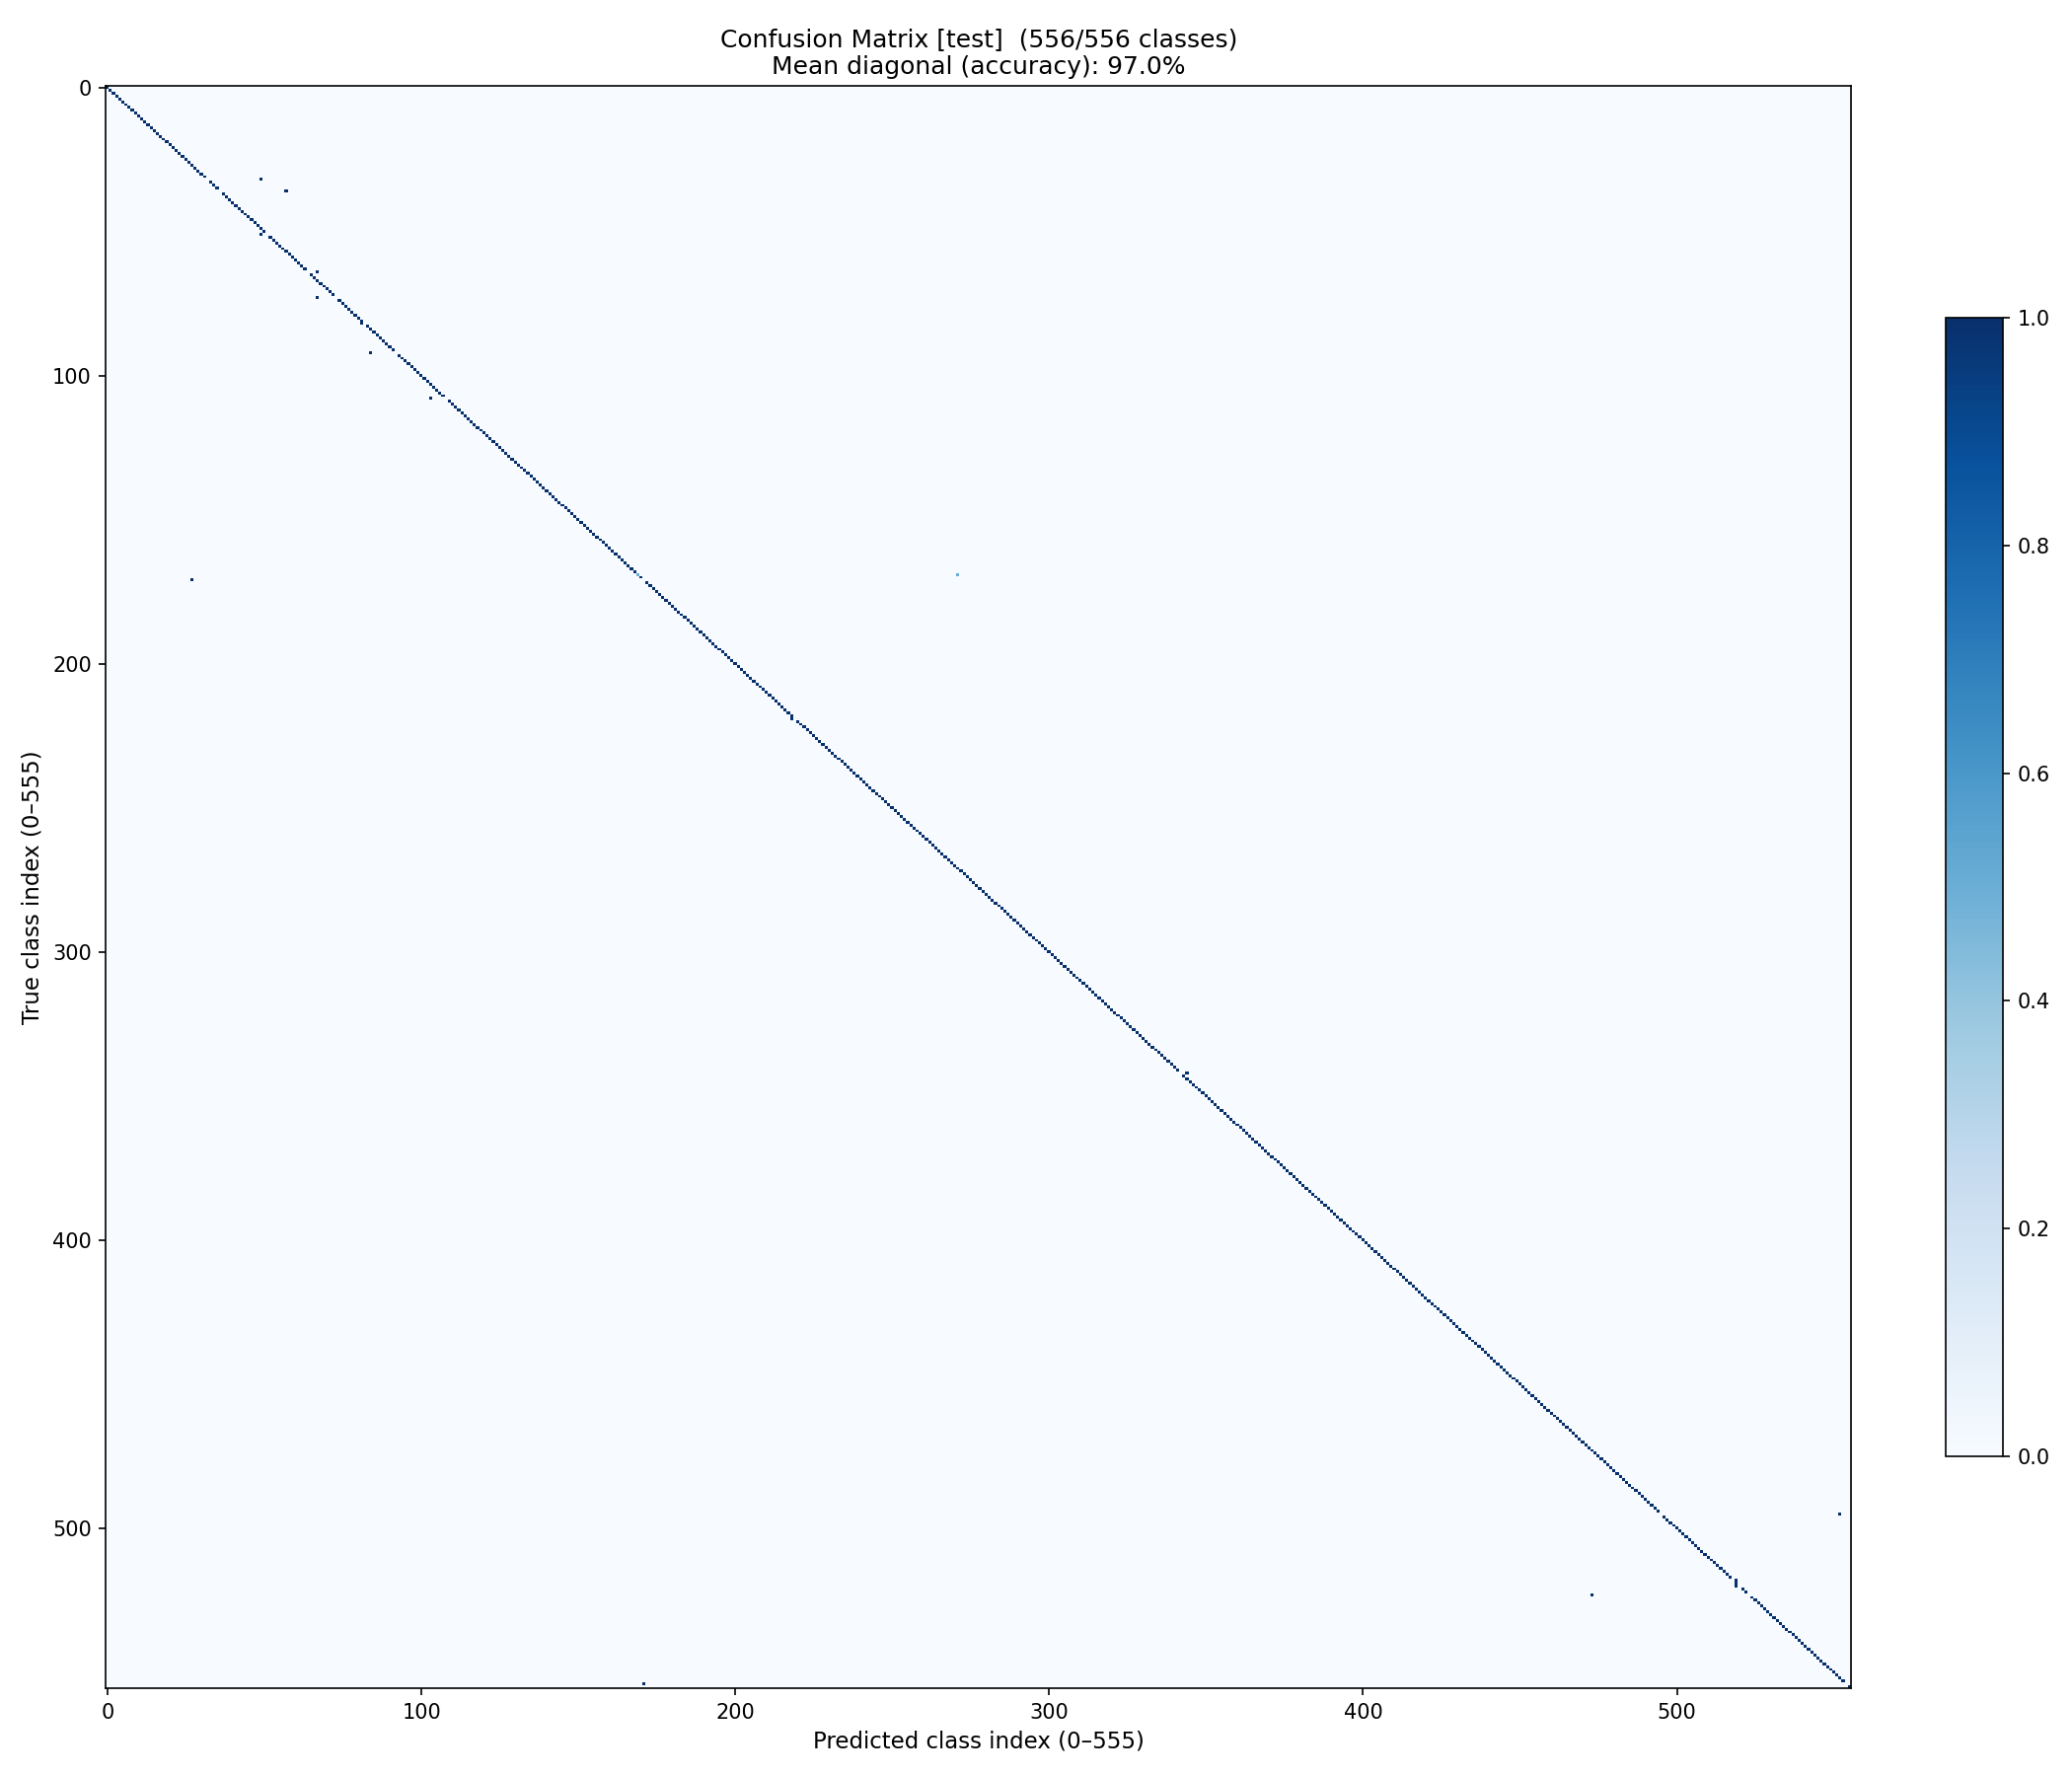

In [42]:
from IPython.display import Image, display

# Replace this path if your file is in a different subdirectory
image_path = './results/exp_bilstm/evaluation/confusion_matrix_test.png'

display(Image(filename=image_path, width=1000, height=500))

In [39]:
!cat results/exp_bilstm/evaluation/metrics_test.json

{
  "split": "test",
  "num_samples": 558,
  "num_classes": 556,
  "top1_accuracy": 0.9695340501792115,
  "top5_accuracy": 1.0,
  "precision_macro": 0.9586330935251799,
  "recall_macro": 0.9703237410071942,
  "f1_macro": 0.9619304556354916,
  "precision_weighted": 0.9587813620071685,
  "recall_weighted": 0.9695340501792115,
  "f1_weighted": 0.9614695340501792
}

In [40]:
!cat results/exp_bilstm/evaluation/per_class_test.csv

,precision,recall,f1-score,support
မီး ။,1.0,1.0,1.0,1.0
မီး ငြှိမ်း ။,1.0,1.0,1.0,1.0
မီးချိတ် ။,1.0,1.0,1.0,1.0
မီးကပ် ။,1.0,1.0,1.0,1.0
ရေပုံး ။,1.0,1.0,1.0,1.0
သဲ အိတ် ။,1.0,1.0,1.0,1.0
မီးသတ်ဆေးဘူး ။,1.0,1.0,1.0,1.0
မီးသတ်ရေကန် ။,1.0,1.0,1.0,1.0
မီးလောင် လွယ် သော ပစ္စည်း များ ။,1.0,1.0,1.0,1.0
လောင်စာဆီ ။,1.0,1.0,1.0,1.0
အမှိုက် ။,1.0,1.0,1.0,1.0
လျှပ်စစ် မီး ။,1.0,1.0,1.0,1.0
ဂက်စ် မီး ။,1.0,1.0,1.0,1.0
မီးကြွင်းမီးကျန် ။,1.0,1.0,1.0,1.0
မီးခလုပ် ။,1.0,1.0,1.0,1.0
မီးခြစ် ။,1.0,1.0,1.0,1.0
ဖယောင်းတိုင် ။,1.0,1.0,1.0,1.0
ခြင်ဆေးခွေ ။,1.0,1.0,1.0,1.0
အမွှေးတိုင် ။,1.0,1.0,1.0,1.0
မီးခိုး ။,1.0,1.0,1.0,1.0
အောက်စီဂျင် ။,1.0,1.0,1.0,1.0
ထွက်ပေါက် ။,1.0,1.0,1.0,1.0
မီးသတ်ကား ။,1.0,1.0,1.0,1.0
မီးသတ်သမား ။,1.0,1.0,1.0,1.0
မီးသတ်ဌာန ။,1.0,1.0,1.0,1.0
လျှပ်စစ် ဝါယာ ရှော့ ။,1.0,1.0,1.0,1.0
ရေဘေး ။,1.0,1.0,1.0,1.0
ဘေးအန္တရာယ် ။,0.5,1.0,0.6666666666666666,1.0
မြစ်ခေျာင်း ။,1.0,1.0,1.0,1.0
မြေနိမ့်ဒေသ ။,1.0,1.0,1.0,1.0
ချိုင့် ။,1.0,1.0,1.0,1.0
ရေနုတ်မြောင်း ။,1.0,1.0,1.0,1.0
ရေ လွှမ်းမိုး မ

In [41]:
!wc ./results/exp_bilstm/evaluation/*.csv

   560   4121  60372 ./results/exp_bilstm/evaluation/per_class_test.csv
   560   4121  60889 ./results/exp_bilstm/evaluation/per_class_val.csv
   559   9593 184033 ./results/exp_bilstm/evaluation/predictions_test.csv
   559   9503 183096 ./results/exp_bilstm/evaluation/predictions_val.csv
  2238  27338 488390 total


### Transformer Model Train

In [43]:
!time bash scripts/04_train.sh transformer exp_transformer

 Training MSL Recognition Model
 Model      : transformer
 Experiment : exp_transformer
 Config     : config/config.yaml

 Data: train=10602, val=558, test=558 (all-class design)

[GPU]
NVIDIA GeForce GTX 1050 with Max-Q Design, 4096 MiB, 4036 MiB, 37

2026-07-20 13:53:23.281170: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-20 13:53:24.223912: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-07-20 13:53:27 | INFO     | train | Experiment: exp_transformer  Model: transformer
/home/phantom/Documents/AI_env/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variabl

### Evaluate Transformer Model

In [44]:
!time bash scripts/05_evaluate.sh transformer exp_transformer

 Evaluation — transformer / exp_transformer
 Checkpoint : results/exp_transformer/checkpoints/best.pth
 Output dir : results/exp_transformer/evaluation

── Validation set ──────────────────────────────────────────
/home/phantom/Documents/AI_env/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
2026-07-21 12:59:33 | INFO     | evaluate | Loaded checkpoint: results/exp_transformer/checkpoints/best.pth  Model: transformer
2026-07-21 12:59:33 | INFO     | evaluate | Evaluating 558 samples from 'val' split
2026-07-21 12:59:33 | INFO     | evaluate | Model loaded. Evaluating 558 samples…
/home/phantom/Documents/AI_env/lib/python3.10/site-packages/torch/utils/

In [45]:
!ls ./results/exp_transformer/evaluation/*

./results/exp_transformer/evaluation/confusion_matrix_test.npy
./results/exp_transformer/evaluation/confusion_matrix_test.png
./results/exp_transformer/evaluation/confusion_matrix_val.npy
./results/exp_transformer/evaluation/confusion_matrix_val.png
./results/exp_transformer/evaluation/eval_test.log
./results/exp_transformer/evaluation/eval_val.log
./results/exp_transformer/evaluation/metrics_test.json
./results/exp_transformer/evaluation/metrics_val.json
./results/exp_transformer/evaluation/per_class_test.csv
./results/exp_transformer/evaluation/per_class_val.csv
./results/exp_transformer/evaluation/predictions_test.csv
./results/exp_transformer/evaluation/predictions_val.csv


In [46]:
!cat ./results/exp_transformer/evaluation/predictions_val.csv | head -n 30 

sample_idx,true_label,pred_label,correct,true_idx,pred_idx,confidence,video_path,msl_gloss
0,မီး ။,မီး ။,True,0,0,0.9728700518608093,data/videos/1-50/idx20-1.mp4,မီး
1,မီး ငြှိမ်း ။,မီး ငြှိမ်း ။,True,1,1,0.942812979221344,data/videos/1-50/idx20-2.mp4,မီး ငြှိမ်း
2,မီးချိတ် ။,မီးချိတ် ။,True,2,2,0.9536303877830505,data/videos/1-50/idx20-3.mp4,မီးချိတ်
3,မီးကပ် ။,မီးကပ် ။,True,3,3,0.9293110370635986,data/videos/1-50/idx20-4.mp4,မီးကပ်
4,ရေပုံး ။,ရေပုံး ။,True,4,4,0.8610301613807678,data/videos/1-50/idx20-5.mp4,ရေပုံး
5,သဲ အိတ် ။,သဲ အိတ် ။,True,5,5,0.9004915952682495,data/videos/1-50/idx20-6.mp4,အိတ် ထဲ သဲ
6,မီးသတ်ဆေးဘူး ။,မီးသတ်ဆေးဘူး ။,True,6,6,0.9241884350776672,data/videos/1-50/idx20-7.mp4,အနီ ဘူး ဖြန်း
7,မီးသတ်ရေကန် ။,မီးသတ်ရေကန် ။,True,7,7,0.9689913988113403,data/videos/1-50/Idx20-8.mp4,ကန် ထဲ ရေ သိမ်း
8,မီးလောင် လွယ် သော ပစ္စည်း များ ။,မီးလောင် လွယ် သော ပစ္စည်း များ ။,True,8,8,0.9317637085914612,data/videos/1-50/idx20-9.mp4,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
9,လေ

In [47]:
!cat ./results/exp_transformer/evaluation/predictions_val.csv | tail -n 30 

528,ဘယ် နေရာ က နာ တာ လဲ ။,ဘယ် နေရာ က နာ တာ လဲ ။,True,526,526,0.967018723487854,data/videos/501-558/idx20-529.mp4,ခန္ဓာကိုယ် နာ ပြဿနာ ဘာလဲ
529,ဆေး မ တည့် တာ တွေ ရှိ လား ။,ဆေး မ တည့် တာ တွေ ရှိ လား ။,True,527,527,0.9354800581932068,data/videos/501-558/idx20-530.mp4,ဆေး မတည့် ရှိလား
530,အစားသောက် မ တည့် တာ တွေ ရှိ လား ။,အစားသောက် မ တည့် တာ တွေ ရှိ လား ။,True,528,528,0.969417929649353,data/videos/501-558/idx20-531.mp4,မင်း အစား မတည့် ရှိလား
531,ကျွန်တော် ပုဇွန် နဲ့ ဓာတ် မ တည့် ဘူး ။,ကျွန်တော် ပုဇွန် နဲ့ ဓာတ် မ တည့် ဘူး ။,True,529,529,0.8844766020774841,data/videos/501-558/idx20-532.mp4,ငါ ပုဇွန် စား မတည့် ယားတယ်
532,ကျွန်တော် ပင်နယ်ဆလင် နဲ့ ဓာတ် မ တည့် ဘူး ။,ကျွန်တော် ပင်နယ်ဆလင် နဲ့ ဓာတ် မ တည့် ဘူး ။,True,530,530,0.9682000279426575,data/videos/501-558/idx20-533.mp4,ငါ ဆေး နာမည် ပ င ် န ယ ် ဆfs လ င ် သောက် မတည့် ယား နီ မျက်နှာနီယား
533,နည်းနည်း လှုပ်ရှား လိုက် တာ နဲ့ မော နေ တယ် ။,နည်းနည်း လှုပ်ရှား လိုက် တာ နဲ့ မော နေ တယ် ။,True,531,531,0.9377986788749695,data/videos/501-558/idx20-534.mp4,လ

In [48]:
!wc ./results/exp_transformer/evaluation/*.csv

   560   4121  60177 ./results/exp_transformer/evaluation/per_class_test.csv
   560   4121  60447 ./results/exp_transformer/evaluation/per_class_val.csv
   559   9599 184072 ./results/exp_transformer/evaluation/predictions_test.csv
   559   9581 184007 ./results/exp_transformer/evaluation/predictions_val.csv
  2238  27422 488703 total


In [13]:
!time bash scripts/04_train.sh stgcn exp_stgcn

 Training MSL Recognition Model
 Model      : stgcn
 Experiment : exp_stgcn
 Config     : config/config.yaml

 Data: train=10602, val=558, test=558 (all-class design)

[GPU]
NVIDIA GeForce GTX 1050 with Max-Q Design, 4096 MiB, 4036 MiB, 38

2026-07-27 11:33:07.363400: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-27 11:33:08.247593: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-07-27 11:33:10 | INFO     | train | Experiment: exp_stgcn  Model: stgcn
2026-07-27 11:33:10 | INFO     | train | Classes: 556
2026-07-27 11:33:10 | INFO     | train | Using all-class manifest: train=10602, val=558, test=558

[DataLoaders]
  Train: 10602 samples, 331 batches
  Val:   558   samples, 18 batches
  Test: 

In [50]:
!time bash scripts/05_evaluate.sh stgcn exp_stgcn

 Evaluation — stgcn / exp_stgcn
 Checkpoint : results/exp_stgcn/checkpoints/best.pth
 Output dir : results/exp_stgcn/evaluation

── Validation set ──────────────────────────────────────────
^C


In [2]:
!ls ./results/exp_stgcn/evaluation/

eval_val.log


In [3]:
!python src/plot_results_v2.py \
      --exp results/exp_bilstm results/exp_transformer results/exp_stgcn \
      --output results/comparison_val.png \
      --output_test results/comparison_test.png

Training curves saved → results/exp_bilstm/training_curves.png
Training curves saved → results/exp_transformer/training_curves.png
No history.json found in results/exp_stgcn
[WARNING] No valid val data in results/exp_stgcn, skipping
Val comparison chart saved → results/comparison_val.png
[WARNING] No valid test data in results/exp_stgcn, skipping
Test comparison chart saved → results/comparison_test.png


### Training Curves of BiLSTM

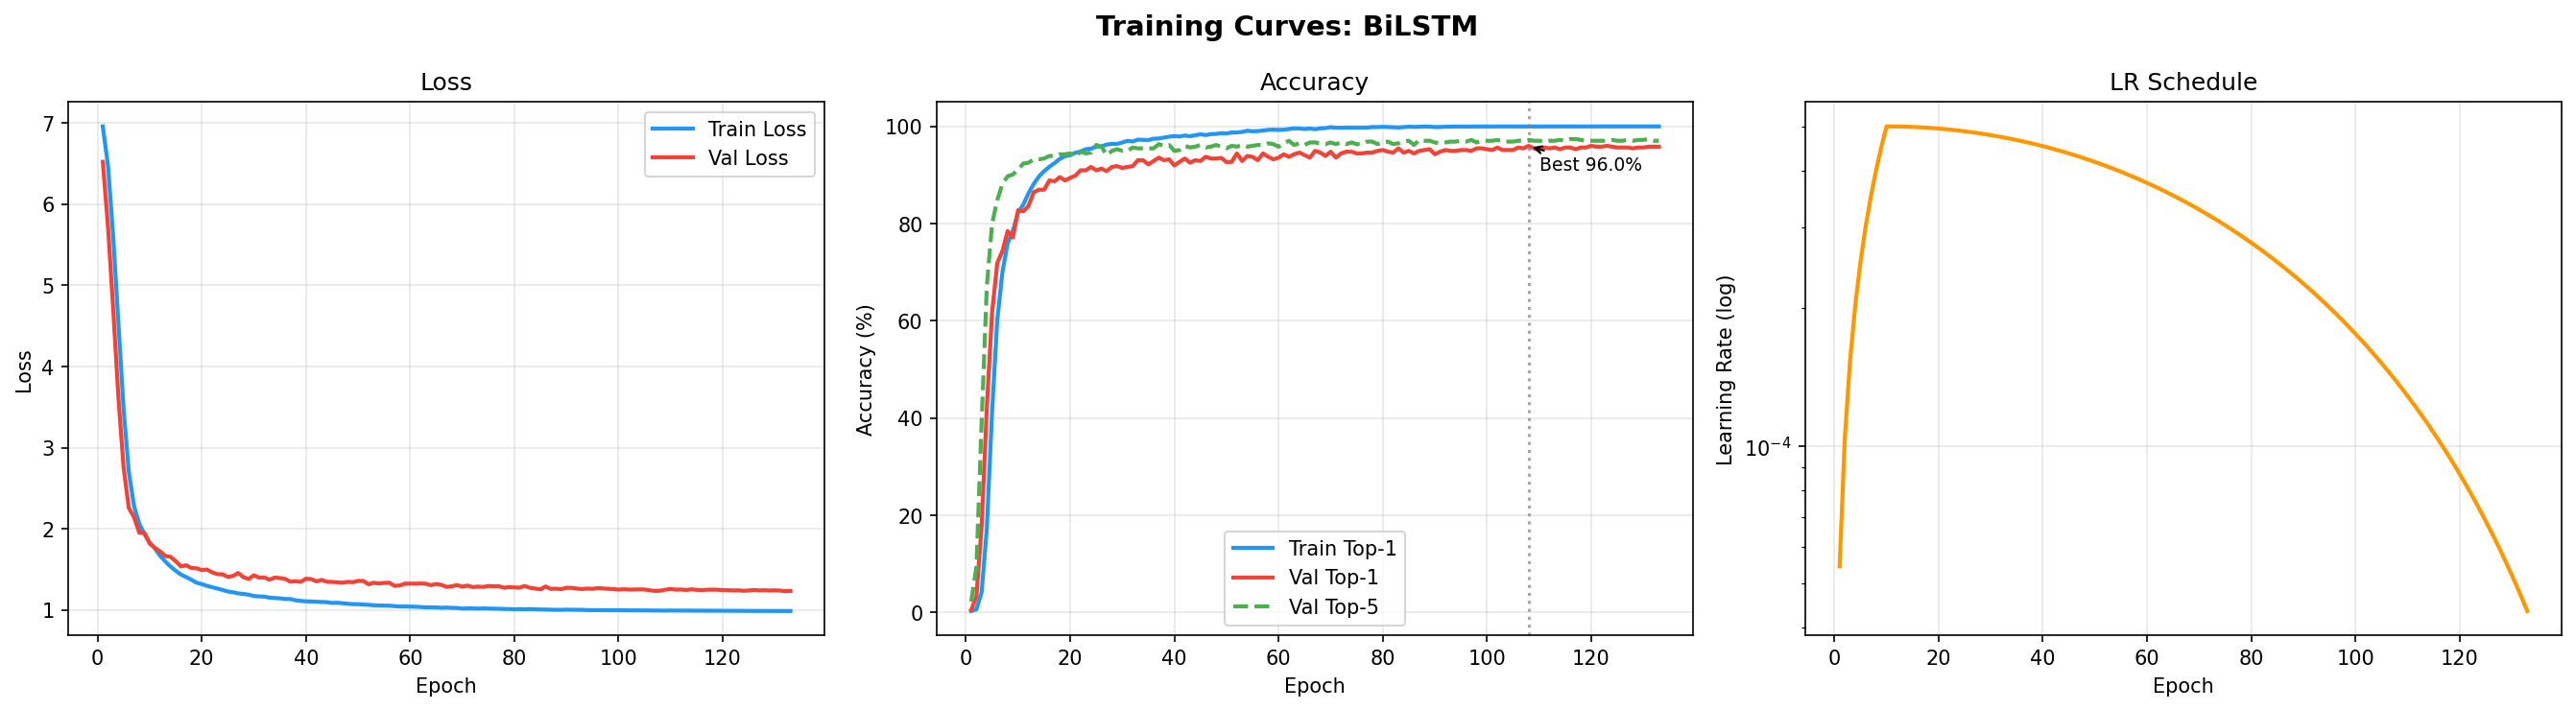

In [4]:
from IPython.display import Image, display

image_path = './results/exp_bilstm/training_curves.png'
display(Image(filename=image_path))

### Training Curve of Transformer

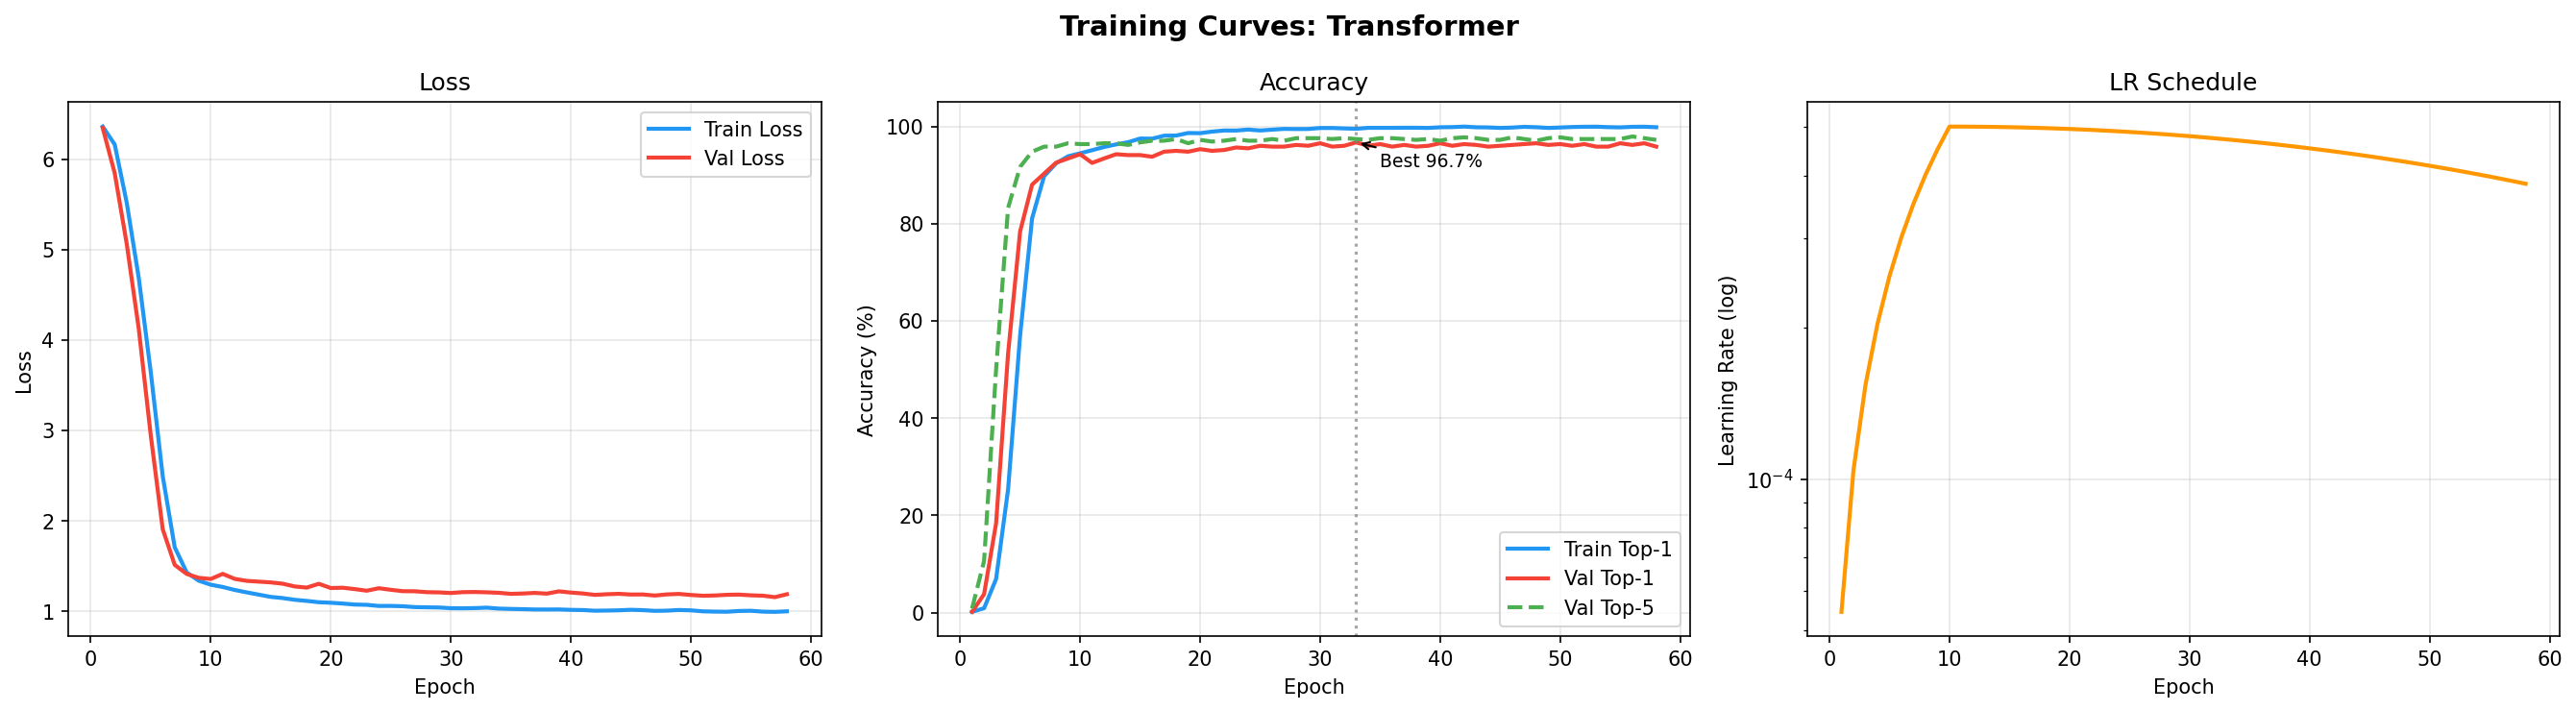

In [5]:
from IPython.display import Image, display

image_path = './results/exp_transformer/training_curves.png'
display(Image(filename=image_path))

### Training Curve of STGCN

In [6]:
from IPython.display import Image, display

image_path = './results/exp_stgcn/training_curves.png'
display(Image(filename=image_path))

FileNotFoundError: [Errno 2] No such file or directory: './results/exp_stgcn/training_curves.png'

### Model Comparison

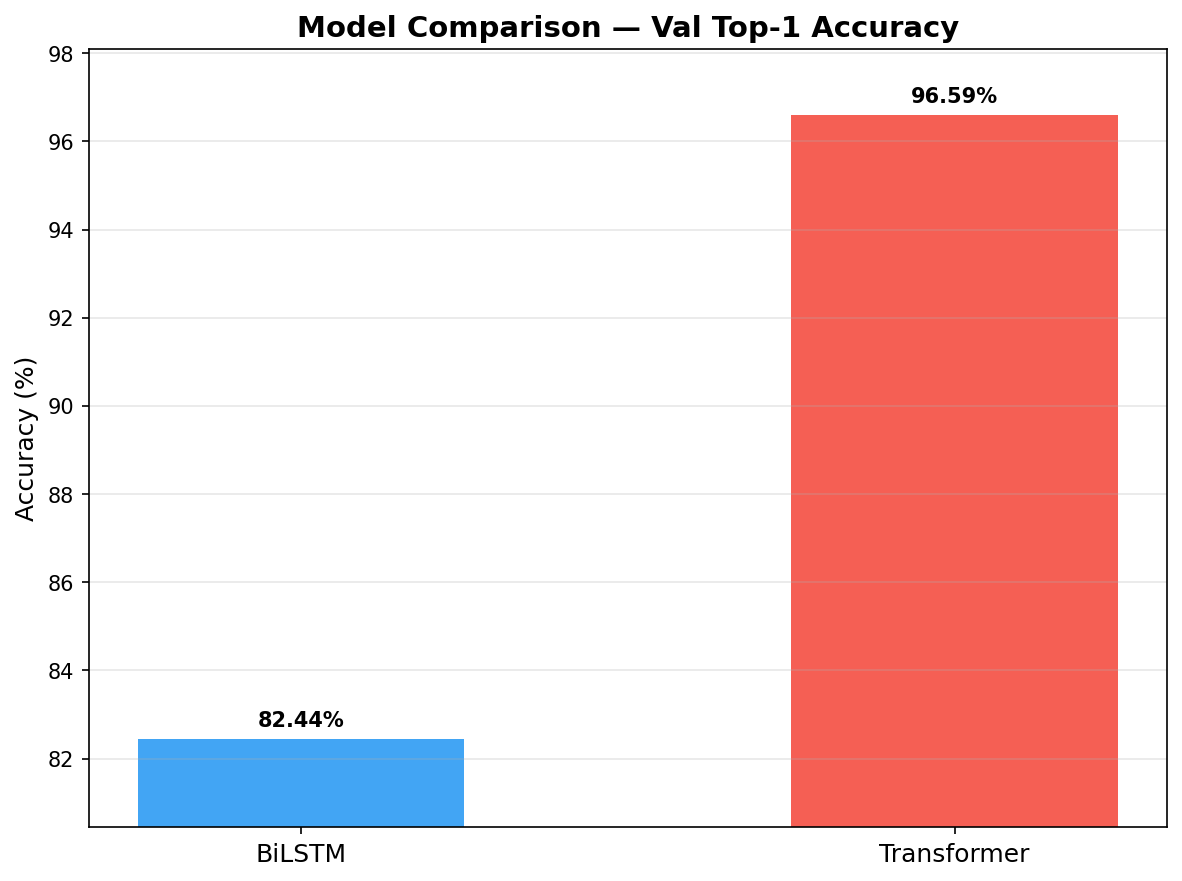

In [7]:
from IPython.display import Image, display

image_path = './results/comparison_val.png'
display(Image(filename=image_path, width=400, height=200))

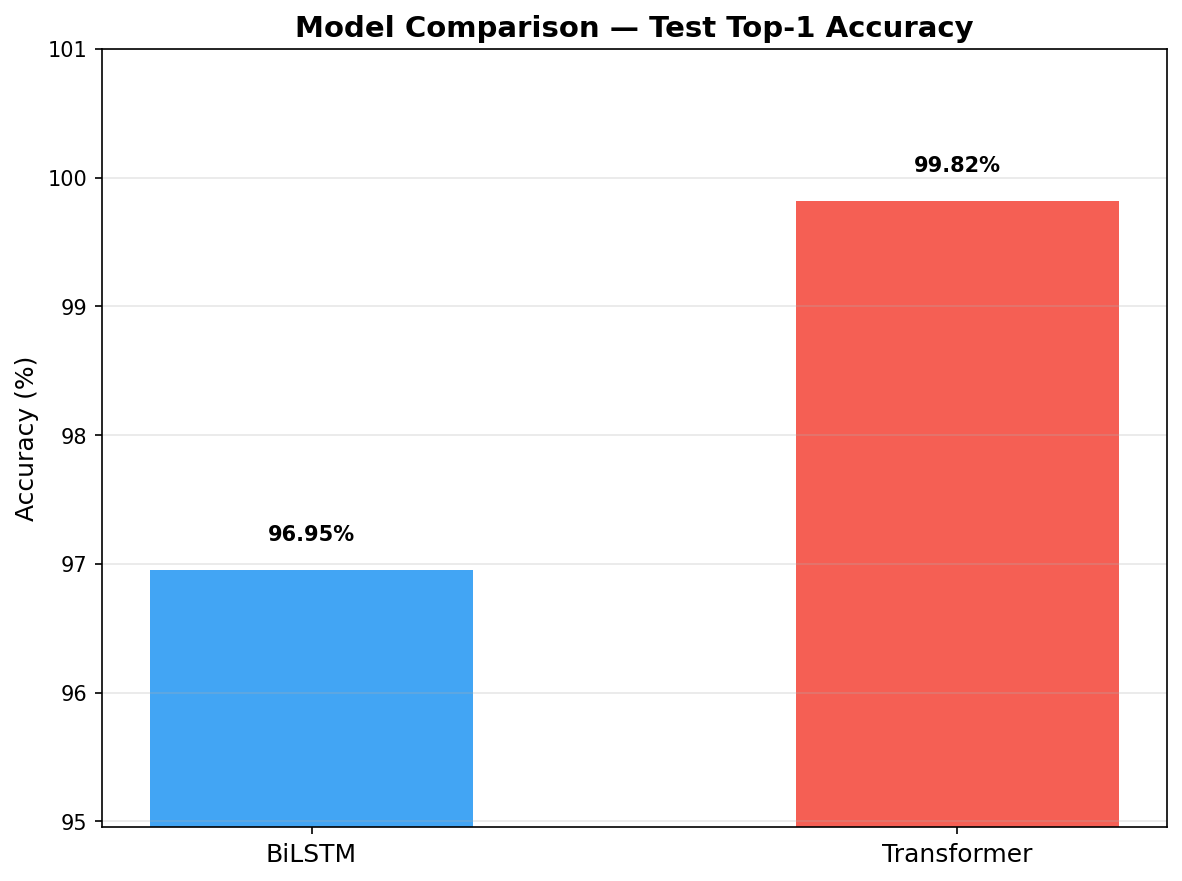

In [8]:
from IPython.display import Image, display

image_path = './results/comparison_test.png'
display(Image(filename=image_path, width=400, height=200))

In [10]:
!python ./scripts/compare_results.py

          Model Performance Comparison (Myanmar Sign Language)
Model         | Val Top-1 Val Top-5   Val F1 | Test Top-1 Test Top-5  Test Prec  Test Rec  Test F1
──────────────────────────────────────────────────────────────────────────────────────────────────
Bi-LSTM       |    82.44%    90.86%   78.85% |     96.95%    100.00%     95.86%    97.03%   96.19%
Transformer   |    96.59%    97.31%   95.44% |     99.82%    100.00%     99.73%    99.82%   99.76%
ST-GCN        |         —         —        — |          —          —          —         —        —
